# Non-centered unmarginalized Fourier posterior

\begin{align*}\log p(\xi, \eta | \delta \mathbf t)&\propto \log p(\eta) + \frac{1}{2}\log \det \phi_0 - \frac{1}{2}\log \det \phi   + \log \det |L| - \frac{1}{2}\xi^T\xi  + \frac{1}{2}b^T\Sigma b.
\end{align*}

\begin{align*}
a = \hat a(\eta) +L(\eta) \xi, \quad \hat a(\eta) = \Sigma(\eta) \Sigma_0^{-1} \hat a_0, \quad \textrm{chol}(\Sigma(\eta)) = L(\eta)
\end{align*}

\begin{align*}
b = \Sigma_0^{-1} \hat a_0
\end{align*}

In [95]:
from fourierpta import *
import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer
import jax
import jax.numpy as jnp
import jax.scipy as jsp

In [96]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

In [ ]:
allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True)

In [ ]:
npsr = 2
psrs = allpsrs[:npsr]

In [ ]:
psrs

[<Pulsar J1713+0747: 59389 res, 423 pars>,
 <Pulsar J1909-3744: 35037 res, 345 pars>]

In [ ]:
powerlaw = ds.powerlaw
rn_init_params = extract_rn_params(psrs)

rn_components = 30
gw_components = 14
N = 10000
ecorr = False 
fixed_wn = True

# Creating the HD Fourier model
pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= rn_init_params, ecorr = ecorr, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn)

pslmodels_nonfixed = fouriermodel(psrs, rn_components, 
                         rn_init_params= {}, ecorr = ecorr, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn)


In [ ]:
priordict_standard = ds.priordict_standard
priordict_standard.update({"(.*_)?red_noise_log10k*": [-9, -4],
                           "(.*_)?dmgp_log10k*": [-12, -4],
})

In [ ]:
res = run_fourier_step(psrs, pslmodels, rn_components=rn_components, 
                       rn_init_params = rn_init_params, powerlaw = powerlaw,
                       fixed_wn = True, priordict=priordict_standard)

ahats, b, sigma0_inv, phi0_inv, quad0, logdet_phi0, logdet_sigma0_inv = res
TNT = sigma0_inv - phi0_inv

In [ ]:
psrnames = [psr.name for psr in pslmodels]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)

In [ ]:
Tspan = ds.getspan(psrs)
commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, rn_components, T=Tspan, name='red_noise')
hdgp = ds.makeglobalgp_fourier(psrs, ds.powerlaw, ds.hd_orf, gw_components, T=Tspan, name='gw')

getN_common = commongp.Phi.getN 
getN_hd = hdgp.Phi.getN

In [ ]:
gw_log10A_key = "gw_log10_A"
gw_gamma_key = "gw_gamma"

In [ ]:
phi_hd_args = (rn_components, gw_components, rn_amp_keys, rn_gamma_keys, 
        gw_log10A_key, gw_gamma_key, getN_common, getN_hd, npsr)

phi_hd_partial = jax.jit(lambda rho: phi_hd(rho, *phi_hd_args))


In [ ]:
xi_keys = [f"xi_{i}" for i in range(2*rn_components*npsr)]

# HD

In [ ]:
def make_model_hd(b, phi, log_const, TNT, npsr, rn_components,
                  rn_amp_keys, rn_gamma_keys, gw_log10A_key, gw_gamma_key):

    def model_hd():
        etas = {}
        for k in rn_amp_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(-20, -11))
        for k in rn_gamma_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(0, 7))
        etas[gw_log10A_key] = numpyro.sample(gw_log10A_key, dist.Uniform(-20, -11))
        etas[gw_gamma_key]  = numpyro.sample(gw_gamma_key,  dist.Uniform(0, 7))

        xi = numpyro.sample("xi", dist.Normal(jnp.zeros(2 * rn_components * npsr),
                                               jnp.ones(2 * rn_components * npsr)))

        phi_inv, logdet_phi = phi(etas)
        sigma_inv = TNT + phi_inv
        L_sigma_inv = jnp.linalg.cholesky(sigma_inv)
        ahat = jsp.linalg.cho_solve((L_sigma_inv, True), b)
        
        Sigma = jnp.linalg.inv(L_sigma_inv @ L_sigma_inv.T)
        L = jnp.linalg.cholesky(Sigma)

        a = numpyro.deterministic("a", ahat + L @ xi) 

        quad_b = b @ ahat
        log_det_L = -jnp.sum(jnp.log(jnp.abs(jnp.diag(L_sigma_inv))))
        logL = 0.5 * quad_b - 0.5 * logdet_phi + log_const + log_det_L

        numpyro.factor("logL", logL)

    return model_hd


model_hd = make_model_hd(b=b, phi=phi_hd_partial, log_const=0.5 * logdet_phi0,
                          TNT=TNT, npsr=npsr, rn_components=rn_components,
                          rn_amp_keys=rn_amp_keys, rn_gamma_keys=rn_gamma_keys,
                          gw_log10A_key=gw_log10A_key, gw_gamma_key=gw_gamma_key)

num_samples = 2000
kernel = infer.NUTS(model_hd)
sampler = infer.MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=1)
sampler.run(jax.random.key(10))

samples = sampler.get_samples()
sampler.print_summary()

sample: 100%|██████████| 3000/3000 [06:25<00:00,  7.78it/s, 127 steps of size 4.09e-02. acc. prob=0.89]



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1713+0747_red_noise_gamma      1.40      0.48      1.43      0.62      2.20    889.37      1.00
  J1713+0747_red_noise_log10_A    -13.60      0.07    -13.60    -13.71    -13.48   3450.51      1.00
    J1909-3744_red_noise_gamma      0.89      0.69      0.69      0.00      1.86    422.19      1.00
  J1909-3744_red_noise_log10_A    -13.72      0.08    -13.72    -13.86    -13.60    859.91      1.00
                      gw_gamma      3.72      1.32      3.74      1.86      6.50   2137.91      1.00
                    gw_log10_A    -15.38      1.56    -14.71    -18.20    -13.81    423.45      1.00
                         xi[0]     -0.01      1.01      0.01     -1.71      1.55   4260.36      1.00
                         xi[1]      0.00      1.02      0.01     -1.68      1.65   4436.47      1.00
                         xi[2]     -0.00      1.01     -0.01     -1.69      1.68   4085.79

In [63]:
def log_prior(etas):
    log10As = jnp.array([etas[k] for k in rn_amp_keys] + [etas[gw_log10A_key]])
    gammas  = jnp.array([etas[k] for k in rn_gamma_keys] + [etas[gw_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

log_prior_rho = jax.jit(log_prior) 

In [ ]:
xi_samples = samples["xi"].reshape(num_samples, npsr * 2*rn_components)
xi_dict = {f""}

In [52]:
xi_dict = {f"xi_{i}": xi_samples[:, i]for i in range(xi_samples.shape[1])}

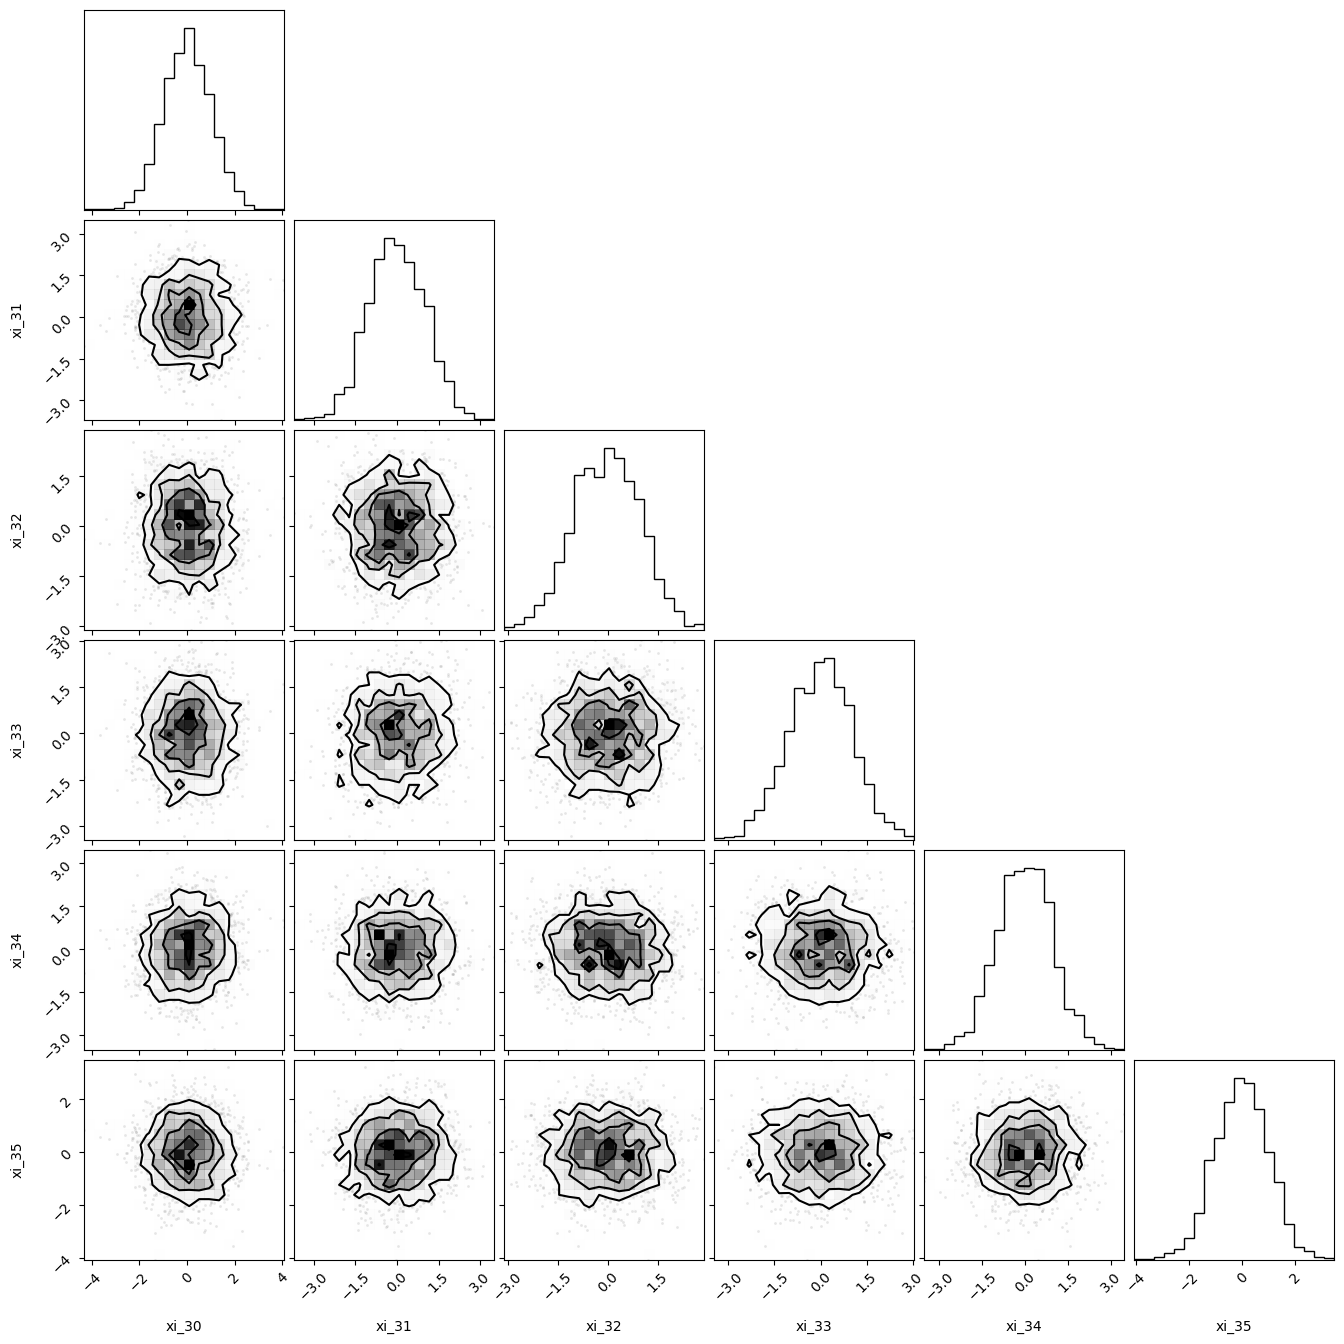

In [53]:
max_xi = 6
xi_base = 30
xi_samples = {key: xi_dict[key] for key in xi_keys[xi_base:xi_base+max_xi]}
corner.corner(xi_samples)
plt.show()

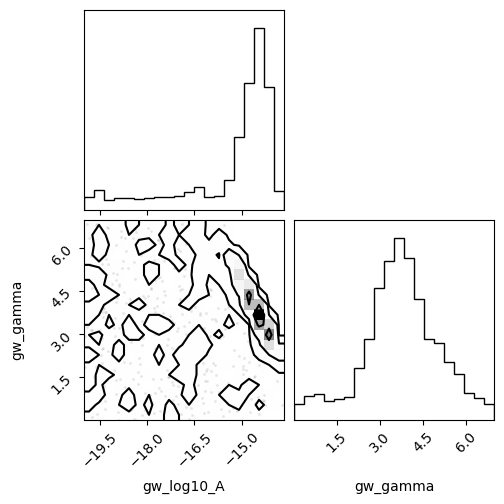

In [54]:
gw_samples = {gw_log10A_key: samples[gw_log10A_key], gw_gamma_key: samples[gw_gamma_key]}
corner.corner(gw_samples)
plt.show()

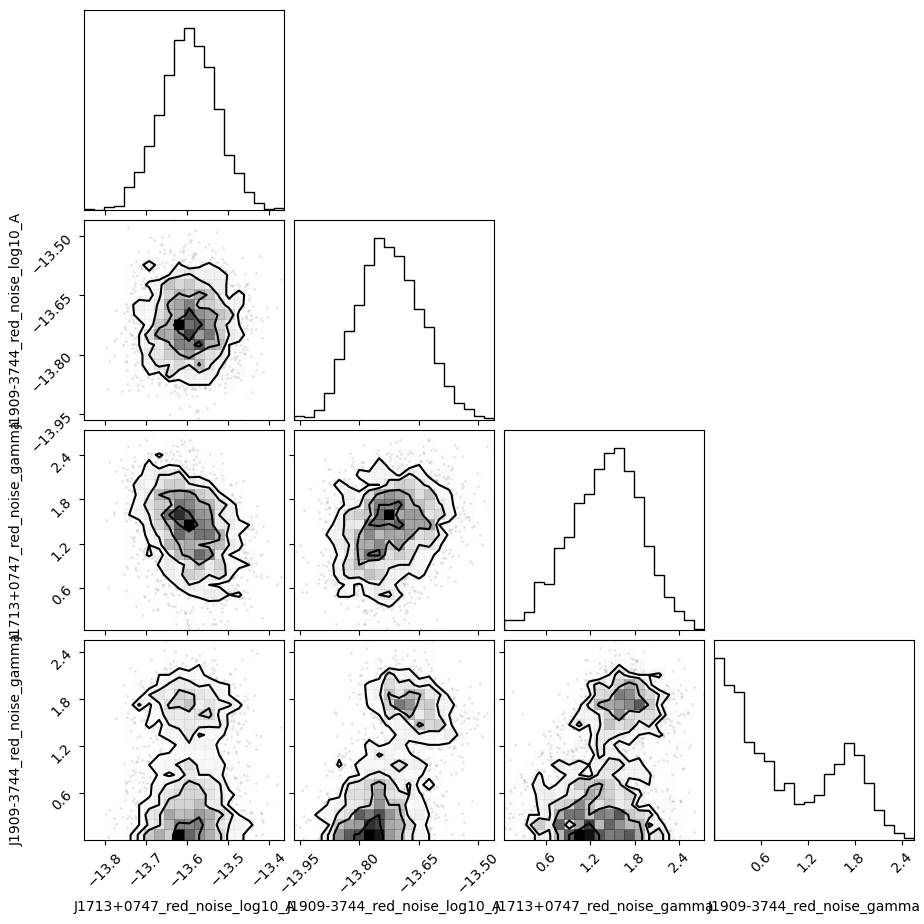

In [55]:
rn_samples = {key: samples[key] for key in rn_amp_keys[:3] + rn_gamma_keys[:3]}
corner.corner(rn_samples)
plt.show()

### Comparing HD with DISCOVERY

In [56]:
m = ds.GlobalLikelihood(pslmodels_nonfixed, globalgp = hdgp)

In [64]:
def potential_ds(rho):
        lp = log_prior_rho(rho)
        return - m.logL(rho) - lp

In [66]:
kernel_ds = infer.NUTS(potential_fn=potential_ds)
sampler_ds = infer.MCMC(kernel_ds, num_warmup=1000, num_samples=2000, num_chains=1, progress_bar=True)

init_rho_hd = {**{key: -12.0 for key in rn_amp_keys},
    **{key: 2.0 for key in rn_gamma_keys},
    gw_log10A_key: -11.50,
    gw_gamma_key: 2.0}

sampler_ds.run(jax.random.key(10), init_params=init_rho_hd)
samples_ds = sampler_ds.get_samples()

sample: 100%|██████████| 3000/3000 [02:41<00:00, 18.56it/s, 11 steps of size 8.18e-02. acc. prob=0.62]


In [67]:
rn_samples_ds = {key: samples_ds[key] for key in rn_amp_keys + rn_gamma_keys}
gw_samples_ds = {key: samples_ds[key] for key in [gw_log10A_key, gw_gamma_key]}

In [75]:
hist_kwargs ={"density": True, "alpha": 0.5, "color": "red"}
hist_kwargs_ds = {"density": True, "alpha": 0.5, "color": "blue"}

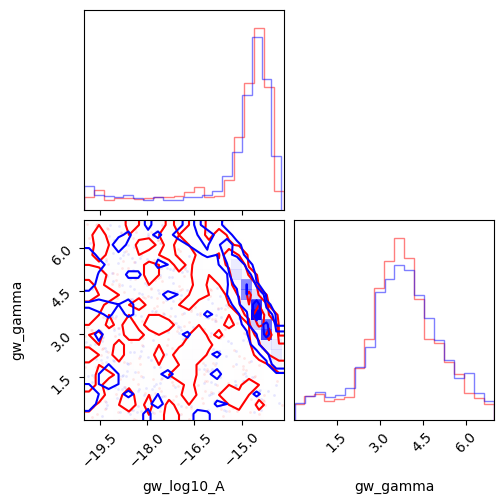

In [76]:
figure = corner.corner(gw_samples,  hist_kwargs=hist_kwargs, color = 'red')
corner.corner(gw_samples_ds,  hist_kwargs=hist_kwargs_ds, color = 'blue', fig=figure)
plt.show()

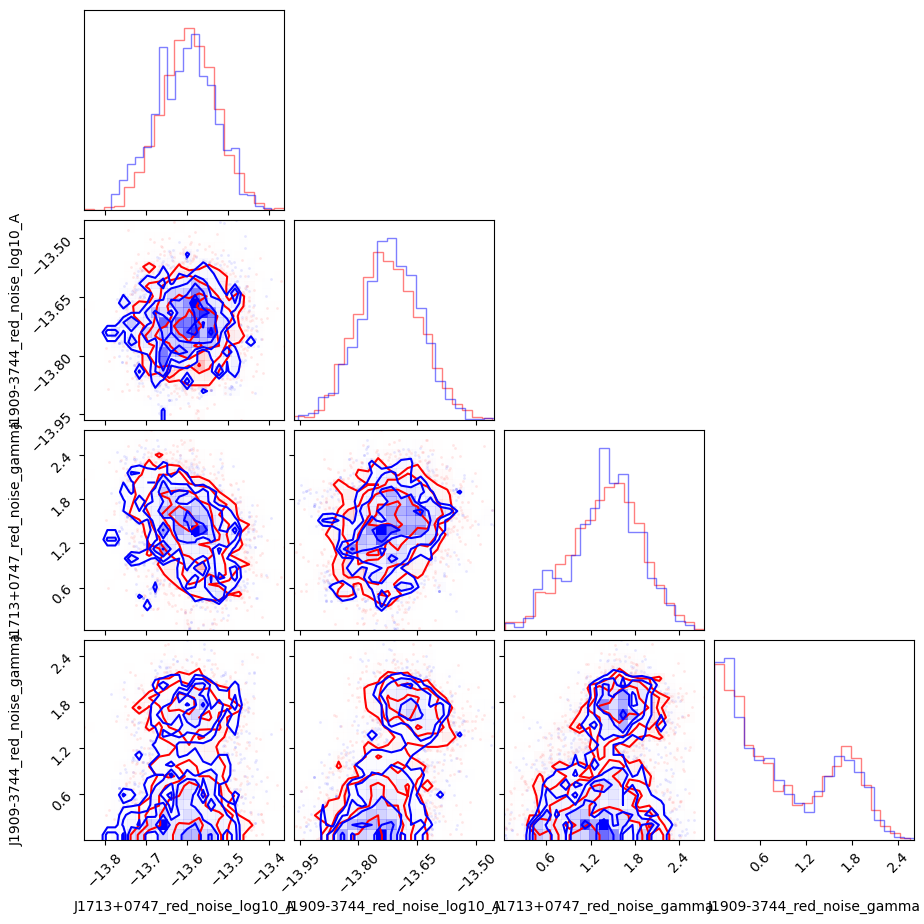

In [77]:
figure = corner.corner(rn_samples,  hist_kwargs=hist_kwargs, color='red')
corner.corner(rn_samples_ds,  hist_kwargs=hist_kwargs_ds, color='blue', fig=figure)
plt.show()

# CRN

In [71]:
crn_gamma_key = "crn_gamma"
crn_log10A_key = "crn_log10_A"
crn_components = 14

In [72]:
commongp_crn =ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])
getN_common = commongp.Phi.getN 
getN_crn = commongp_crn.Phi.getN

In [73]:
phi_crn_args = (crn_components, rn_amp_keys, rn_gamma_keys, crn_log10A_key, 
        crn_gamma_key, getN_common, getN_crn)

phi_crn_partial = jax.jit(lambda rho: phi_crn(rho, *phi_crn_args))

In [87]:
def make_model_crn(b, phi, log_const, TNT, npsr, rn_components,
                  rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key):

    if TNT.shape != (npsr, 2 * rn_components, 2 * rn_components):
         TNT = TNT.reshape(npsr, 2 * rn_components, npsr, 2 * rn_components).diagonal(axis1=0, axis2=2).transpose(2, 0, 1)  # (npsr, 2*rn, 2*rn)
    
    if b.shape != (npsr, 2 * rn_components):
        b = b.reshape(npsr, 2 * rn_components)
    
    def model_crn():
        etas = {}
        for k in rn_amp_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(-20, -11))
        for k in rn_gamma_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(0, 7))
        etas[crn_log10A_key] = numpyro.sample(crn_log10A_key, dist.Uniform(-20, -11))
        etas[crn_gamma_key]  = numpyro.sample(crn_gamma_key,  dist.Uniform(0, 7))

        xi =  numpyro.sample("xi", dist.Normal(jnp.zeros(npsr * 2 * rn_components),
                                               jnp.ones(npsr * 2 * rn_components)))

        phi_inv_diags, logdet_phi = phi(etas)
        xis = xi.reshape(npsr, 2 * rn_components)                 

        sigma_inv  = TNT + jax.vmap(jnp.diag)(phi_inv_diags)                                      
        L_sinv = jax.vmap(jnp.linalg.cholesky)(sigma_inv)                                       
        ahat = jax.vmap(lambda L, b: jsp.linalg.cho_solve((L, True), b))(L_sinv, b)  
        Sigma = jax.vmap(lambda L: jsp.linalg.cho_solve((L, True), jnp.eye(2 * rn_components)))(L_sinv)  
        L = jax.vmap(jnp.linalg.cholesky)(Sigma)                                          
        a = numpyro.deterministic("a", (ahat + jax.vmap(jnp.dot)(L, xis)).ravel())

        quad_b = jnp.sum(jax.vmap(jnp.dot)(b, ahat))
        log_det_L = -jnp.sum(jax.vmap(lambda l: jnp.sum(jnp.log(jnp.diag(l))))(L_sinv))

        logL = 0.5 * quad_b - 0.5 * logdet_phi + log_const + log_det_L
        numpyro.factor("logL", logL)

    return model_crn

model_crn = make_model_crn(b=b, phi=phi_crn_partial, log_const=0.5 * logdet_phi0,
                          TNT=TNT, npsr=npsr, rn_components=rn_components,
                          rn_amp_keys=rn_amp_keys, rn_gamma_keys=rn_gamma_keys,
                          crn_log10A_key=crn_log10A_key, crn_gamma_key=crn_gamma_key)
kernel_crn = infer.NUTS(model_crn)
sampler_crn = infer.MCMC(kernel_crn, num_warmup=2000, num_samples=3000, num_chains=1, progress_bar=True)
sampler_crn.run(jax.random.key(10))

samples_crn = sampler_crn.get_samples()
sampler_crn.print_summary()

sample: 100%|██████████| 5000/5000 [09:20<00:00,  8.93it/s, 127 steps of size 4.60e-02. acc. prob=0.90]



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1713+0747_red_noise_gamma      1.38      0.49      1.44      0.56      2.17   1053.70      1.00
  J1713+0747_red_noise_log10_A    -13.59      0.07    -13.59    -13.71    -13.48   4325.47      1.00
    J1909-3744_red_noise_gamma      0.92      0.70      0.72      0.00      1.90    487.51      1.00
  J1909-3744_red_noise_log10_A    -13.72      0.08    -13.72    -13.85    -13.59   1144.12      1.00
                     crn_gamma      3.67      1.42      3.70      1.53      6.65   2334.63      1.00
                   crn_log10_A    -15.42      1.58    -14.74    -18.29    -13.81    485.65      1.00
                         xi[0]      0.01      0.99      0.01     -1.72      1.57   4604.04      1.00
                         xi[1]      0.01      1.02      0.01     -1.60      1.74   5845.19      1.00
                         xi[2]      0.01      1.01     -0.02     -1.72      1.54   5606.14

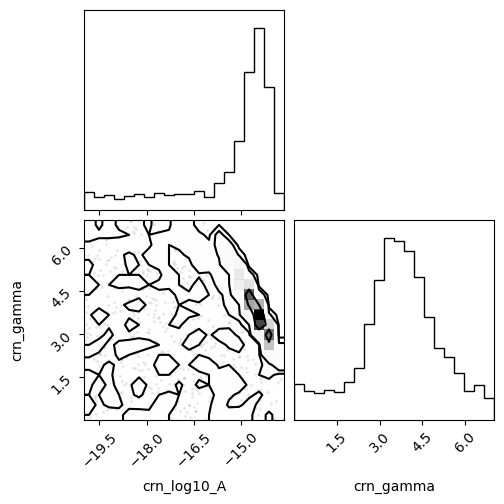

In [88]:
crn_hyperparams = {key: samples_crn[key] for key in ['crn_log10_A', 'crn_gamma']}
corner.corner(crn_hyperparams)
plt.show()

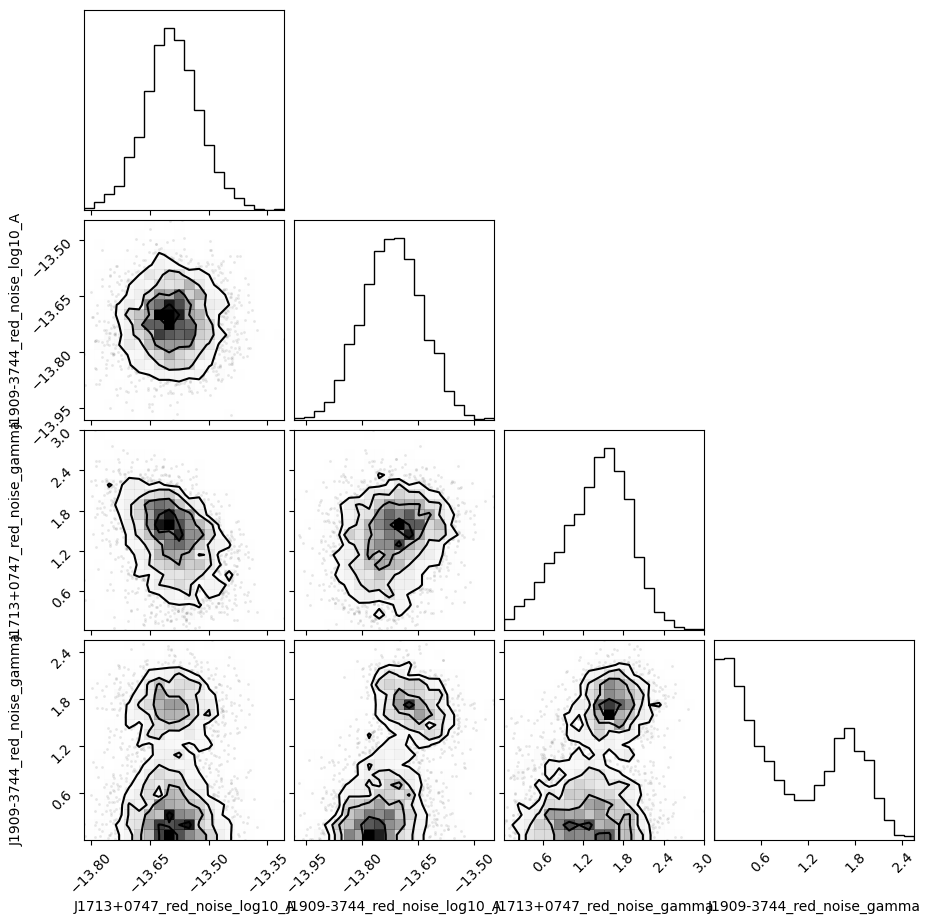

In [89]:
rn_crn_samples = {key: samples_crn[key] for key in rn_amp_keys[:4] + rn_gamma_keys[:4]}
corner.corner(rn_crn_samples)
plt.show()

In [90]:
m_crn = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                          ds.makegp_timing(psr, svd=True),
                                          ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=ecorr)]) for psr in psrs],
                        commongp = [ds.makecommongp_fourier(psrs, ds.powerlaw, components=rn_components, T=Tspan, name='red_noise'),
                                   ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])])

### Comparing with DISCOVERY

In [91]:
def log_prior_rho_crn(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys] + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys] + [rho[crn_gamma_key]])

    # use OK jnp all
    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds_crn(rho):
        lp = log_prior_rho_crn(rho)
        return - m_crn.logL(rho) - lp
    
kernel_ds_crn = infer.NUTS(potential_fn=potential_ds_crn)
sampler_ds_crn = infer.MCMC(kernel_ds_crn, num_warmup=2000, num_samples=3000, progress_bar=True)
init_rho_crn = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0,
    crn_gamma_key: 4.0}

sampler_ds_crn.run(jax.random.key(0), init_params=init_rho_crn)

samples_ds_crn = sampler_ds_crn.get_samples()
sampler_ds_crn.print_summary()


sample: 100%|██████████| 5000/5000 [02:56<00:00, 28.34it/s, 33 steps of size 3.87e-02. acc. prob=0.90] 


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1713+0747_red_noise_gamma      1.46      0.48      1.51      0.67      2.28    139.98      1.02
  J1713+0747_red_noise_log10_A    -13.59      0.07    -13.60    -13.70    -13.48    262.92      1.00
    J1909-3744_red_noise_gamma      0.87      0.69      0.62      0.00      1.88     71.38      1.01
  J1909-3744_red_noise_log10_A    -13.72      0.08    -13.72    -13.86    -13.59    118.72      1.00
                     crn_gamma      3.66      1.39      3.70      1.43      6.49    210.67      1.01
                   crn_log10_A    -15.42      1.57    -14.73    -18.39    -13.87     77.53      1.01

Number of divergences: 2481


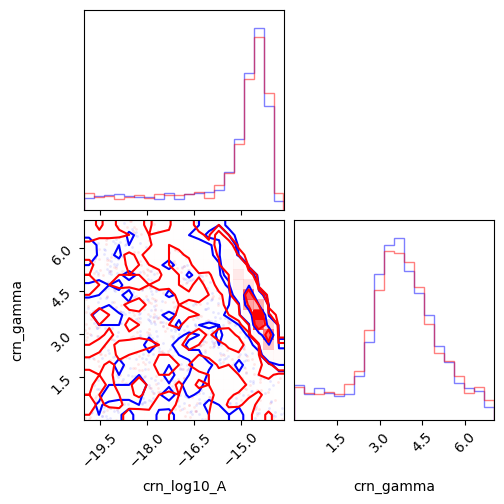

In [92]:
crn_ds_hyperparams = {key: samples_ds_crn[key] for key in ['crn_log10_A', 'crn_gamma']}
figure = corner.corner(crn_ds_hyperparams, hist_kwargs = hist_kwargs_ds, color='blue')
corner.corner(crn_hyperparams, hist_kwargs=hist_kwargs, color='red', fig=figure)
plt.show()

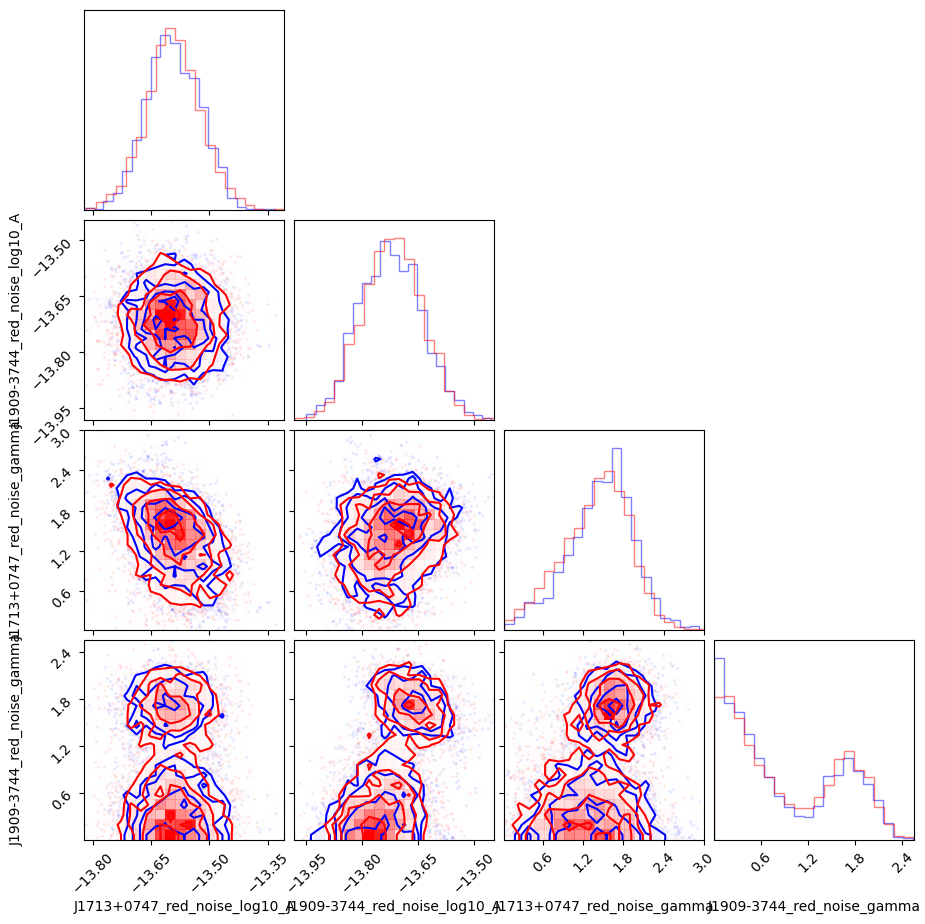

In [93]:
crn_ds_irns = {key: samples_ds_crn[key] for key in rn_amp_keys[:4] + rn_gamma_keys[:4]}
crn_irns = {key: samples_crn[key] for key in rn_amp_keys[:4] + rn_gamma_keys[:4]}
figure = corner.corner(crn_ds_irns, hist_kwargs = hist_kwargs_ds, color='blue')
corner.corner(crn_irns, hist_kwargs=hist_kwargs, color='red', fig=figure)
plt.show()

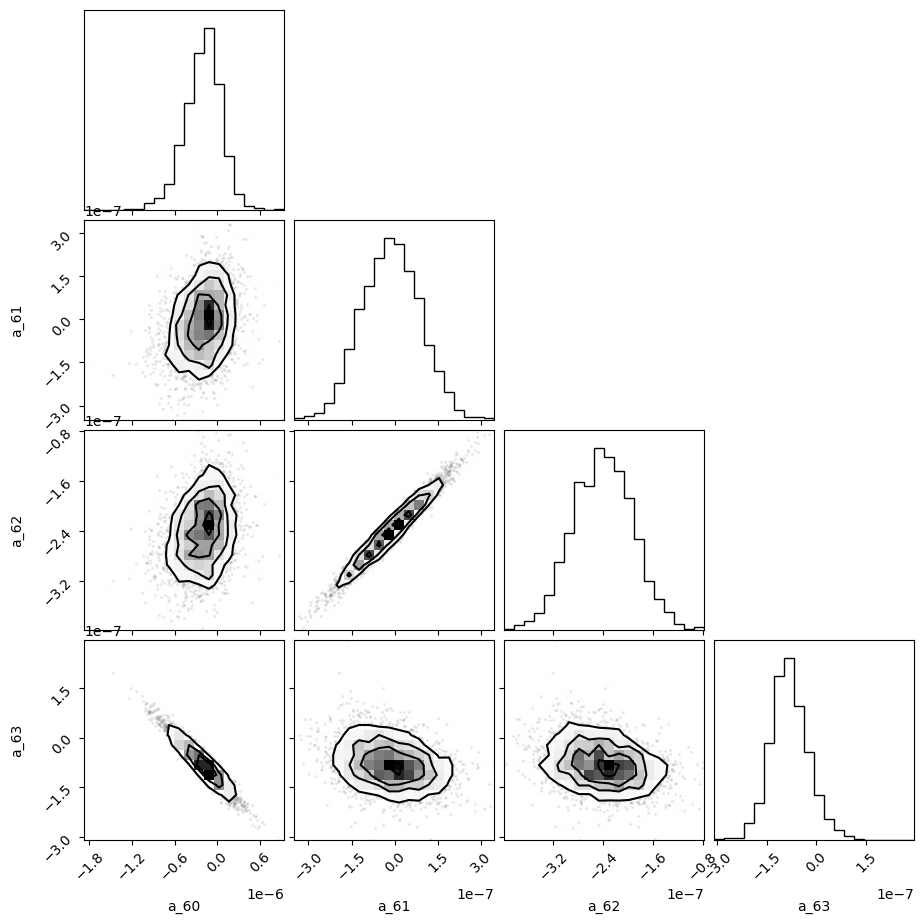

In [94]:
a_samples = samples_crn['a']
a_samples_subset = {f"a_{i}": a_samples[:, i] for i in list(range(60, 64))}
corner.corner(a_samples_subset)
plt.show()